# Classification Basics


**Before running this notebook, make sure to check `00_environment_setup.md` to see whether you have set the environment correctly.**

In this notebook we'll provide a basic guide to classification using the sklearn library. Make sure to check the `01_classification_metrics.ipynb` notebook for an introduction to classification metrics.



## Outline

1. Recap: What is the classification process?
2. Dataset Description
3. Data splits
4. Binary classification
5. Multi-label classification
6. Multi-class classification

## 1. Recap: What is the classification process?

- We select features to describe our data 
    * We provide a number of features for you, derived from standard signal processing techniques for audio classification.
- We label each datapoint based on what we want the model to learn.
    * You did that during the data annotation phase!
    * Ideally, during the data exploration phase, you gained some insights into which features might be correlated with each other, and which features are more correlated with the labels, and thus could help us predict the labels.
- The features + labels creates our **dataset**
- We pass this to a model and hope it finds some connections between the features and the labels training.

In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from typing import Tuple, List, Dict, Optional, Literal, Union

## 2. Dataset Description

The dataset was **recorded and annotated by you** during the first phases of the project.

### Folder structure

```
MLPC2026_dataset_development.zip
|-- metadata.csv
|-- annotations.csv
\-- audio_features/
    |-- 000001.npz
    |-- 000002.npz
    \-- ...
```

- ```metadata.csv``` contains metadata information about each file.
- ```annotations.csv``` contains the label annotations and their regions (onsets + offsets).
- ```audio_features/``` contains the precomputed audio features.

We also provide an additional zip archive containing the raw audio files, should you wish to use them (not covered in this tutorial). Find more details about the features and metadata in the [Data Exploration Task description](https://moodle.jku.at/pluginfile.php/13827494/mod_resource/content/8/MLPC_2026S___Data_Exploration-1.pdf).


In [3]:
# TODO: MAKE SURE TO CHANGE THE PATH TO THE DATASET HERE!
# Remember that Windows and Linux/Mac handle paths differently.
PATH_TO_DATASET = "MLPC2026_dataset_development"

assert os.path.exists(
    PATH_TO_DATASET
), "The dataset folder 'MLPC2026_dataset' does not exist; download the data set and extract its content."
assert os.path.exists(
    os.path.join(PATH_TO_DATASET, "annotations.csv")
), "The file 'MLPC2026_dataset/annotations.csv' does not exist."
assert os.path.exists(
    os.path.join(PATH_TO_DATASET, "metadata.csv")
), "The file 'MLPC2026_dataset/metadata.csv' does not exist."
assert os.path.exists(
    os.path.join(PATH_TO_DATASET, "audio_features")
), "The folder 'MLPC2026_dataset/audio_features' does not exist."

In [14]:
rng = np.random.default_rng(seed=42)

all_audio_features_paths = glob.glob(
    os.path.join(PATH_TO_DATASET, "audio_features", "*.npz")
)
# TODO: Instead of using all files, we will choose just a few,
# otherwise it will take a long time to do all of the experiments
select_subset = 0.2
print(f"Selecting {select_subset}% of the dataset")
audio_features_paths = rng.choice(
    all_audio_features_paths,
    size=int(len(all_audio_features_paths) * select_subset),
    replace=False,
).tolist()

Selecting 0.2% of the dataset


As a reminder, here is the information contained in each of the files:

In [16]:
# These are the features computed
# using signal processing techniques
# directly on the audio files.
FEATURE_NAMES = [
    "zcr_mean",
    "zcr_std",
    "zcr_min",
    "zcr_max",
    "melspect_mean",
    "melspect_std",
    "melspect_min",
    "melspect_max",
    "mfcc_mean",
    "mfcc_std",
    "mfcc_min",
    "mfcc_max",
    "mfcc_d_mean",
    "mfcc_d_std",
    "mfcc_d_min",
    "mfcc_d_max",
    "mfcc_d2_mean",
    "mfcc_d2_std",
    "mfcc_d2_min",
    "mfcc_d2_max",
    "flux_mean",
    "flux_std",
    "flux_min",
    "flux_max",
    "flatness_mean",
    "flatness_std",
    "flatness_min",
    "flatness_max",
    "centroid_mean",
    "centroid_std",
    "centroid_min",
    "centroid_max",
    "bandwidth_mean",
    "bandwidth_std",
    "bandwidth_min",
    "bandwidth_max",
    "contrast_mean",
    "contrast_std",
    "contrast_min",
    "contrast_max",
    "rolloff_low_mean",
    "rolloff_low_std",
    "rolloff_low_min",
    "rolloff_low_max",
    "rolloff_high_mean",
    "rolloff_high_std",
    "rolloff_high_min",
    "rolloff_high_max",
    "energy_mean",
    "energy_std",
    "energy_min",
    "energy_max",
    "power_mean",
    "power_std",
    "power_min",
    "power_max",
]

# These are meta data contained in each of the files
METADATA_NAMES = [
    "start_time",
    "end_time",
    "annotations",
    "is_own_recording",
    "class_names",
    "annotator_ids",
    "target_classes",
    "non_target_classes",
    "recording_device",
    "recording_environments",
    "scene_description",
    "device_placement",
]

# Finally, as a reminder, these are the names of our target classes
# which you helped annotate. Thank you everyone for your effort! ;)
CLASSES_NAMES = [
    "bell_ringing",
    "coffee_machine",
    "cutlery_dishes",
    "door_open_close",
    "footsteps",
    "keyboard_typing",
    "keychain",
    "light_switch",
    "microwave",
    "phone_ringing",
    "running_water",
    "toilet_flushing",
    "vacuum_cleaner",
    "wardrobe_drawer_open_close",
    "window_open_close",
]

We then specify a function to load the data. Note that this function supports three modes: "binary", "multiclass" and "multilabel" classification (we learned about them in our previous notebook `01_classification_metrics.ipynb`, so check it out if you need a reminder.)

In [17]:
def get_features_and_targets(
    filename: str,
    label_type: Literal["binary", "multiclass", "multilabel"] = "multilabel",
) -> Tuple[np.ndarray, Union[np.ndarray, Dict[str, np.ndarray]]]:
    """Load audio features and aggregated target labels from a .npz file.

    Parameters
    ----------
    filename : str
        Path to the .npz file containing audio features and annotations.
    label_type : {"binary", "multiclass", "multilabel"}
        How to encode the targets:
        - "multilabel": binary matrix of shape (T, C), one column per class.
        - "multiclass": integer class index of shape (T, 1), argmax over classes.
        - "binary": dict mapping each class name to a binary array of shape (T, 1).

    Returns
    -------
    x : np.ndarray of shape (T, D)
        Feature matrix with T time frames and D feature dimensions.
    y : np.ndarray of shape (T, C) or (T, 1), or Dict[str, np.ndarray]
        Labels in the format specified by ``label_type``.
    """
    audio_features = dict(np.load(filename, allow_pickle=True))
    annotations = audio_features["annotations"]
    T, C, _ = annotations.shape

    # Concatenate all features
    x = np.empty(
        (
            T,
            sum(
                audio_features[f].shape[1] if audio_features[f].ndim > 1 else 1
                for f in FEATURE_NAMES
            ),
        )
    )
    col = 0
    for feat_name in FEATURE_NAMES:
        feat = audio_features[feat_name]
        width = feat.shape[1] if feat.ndim > 1 else 1
        x[:, col : col + width] = feat if feat.ndim > 1 else feat[:, None]
        col += width

    # Majority-vote aggregation across annotators
    annotations = (annotations > 0).astype(int) # this threshold could be improved
    votes = annotations.sum(axis=2)  # (T, C)

    if label_type == "multilabel":
        y = (votes > (annotations.shape[-1] // 2)).astype(int)
    elif label_type == "multiclass":
        y = np.argmax(votes, axis=1).astype(int).reshape(T, 1)
    else:  # "binary"
        y = make_binary_targets((votes > (annotations.shape[-1] // 2)).astype(int))

    return x, y


def make_binary_targets(Y: np.ndarray) -> Dict[str, np.ndarray]:
    """Convert a multilabel indicator matrix into per-class binary arrays.

    Parameters
    ----------
    Y : np.ndarray of shape (N, C)
        Binary multilabel matrix with N frames and C classes.

    Returns
    -------
    Y_binary : dict of {str: np.ndarray}
        Dictionary mapping each class name in ``CLASSES_NAMES`` to a binary
        array of shape (N, 1).
    """
    return {
        class_name: Y[:, idx].reshape(-1, 1).astype(int)
        for idx, class_name in enumerate(CLASSES_NAMES)
    }

In [18]:
def read_files(
    file_list: List[str],
    label_type: Literal["binary", "multiclass", "multilabel"] = "multilabel",
) -> Tuple[np.ndarray, Union[np.ndarray, Dict[str, np.ndarray]]]:
    """Load and stack features and labels from a list of .npz files.

    Parameters
    ----------
    file_list : list of str
        Paths to .npz audio feature files to load.
    label_type : {"binary", "multiclass", "multilabel"}
        Passed through to ``get_features_and_targets``; controls the format of
        the returned labels.

    Returns
    -------
    X : np.ndarray of shape (N, D)
        Stacked feature matrix across all files.
    Y : np.ndarray of shape (N, C) or (N, 1), or Dict[str, np.ndarray]
        Stacked labels in the format specified by ``label_type``.
    """
    if label_type not in ("binary", "multiclass", "multilabel"):
        raise ValueError(
            f"`label_type` must be 'binary', 'multiclass', or 'multilabel', got {label_type!r}"
        )
    X = []
    Y = []

    for filename in file_list:
        x, y = get_features_and_targets(filename, label_type=label_type)
        X.append(x)
        Y.append(y)

    X = np.vstack(X)

    if label_type == "binary":
        return X, {cls: np.vstack([y[cls] for y in Y]) for cls in CLASSES_NAMES}
    else:
        return X, np.vstack(Y)

### Task 0: Baseline Classifier

**Implementation Task**: Create a binary classifier that predicts the class that is most frequent in the training dataset. You can find our solution below.

In [19]:
class BaselineClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self):
        self.majority_class = None

    def fit(self, x_train: np.ndarray, y_train: np.ndarray) -> None:
        """Fit the classifier by finding the majority class.

        Parameters
        ----------
        x_train : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions. Not used directly,
            included for API consistency.
        y_train : np.ndarray of shape (N,)
            Binary labels (0 or 1) for each training sample.

        Raises
        ------
        NotImplementedError
            This method must be implemented by the student.
        """
        raise NotImplementedError

    def predict(self, x: np.ndarray) -> np.ndarray:
        """Predict binary labels for each sample.

        Parameters
        ----------
        x : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions.

        Returns
        -------
        predictions : np.ndarray of shape (N,)
            Predicted binary labels (all equal to the majority class).

        Raises
        ------
        NotImplementedError
            This method must be implemented by the student.
        """
        raise NotImplementedError

In [21]:
# solution
class BaselineClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self):
        self.majority_class = None

    def fit(self, x_train: np.ndarray, y_train: np.ndarray) -> None:
        """Fit the classifier by finding the majority class.

        Parameters
        ----------
        x_train : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions. Not used directly,
            included for API consistency.
        y_train : np.ndarray of shape (N,)
            Binary labels (0 or 1) for each training sample.
        """
        self.classes_ = np.unique(y_train)
        self.majority_class = 1 if sum(y_train) > len(y_train) / 2 else 0

    def predict(self, x: np.ndarray) -> np.ndarray:
        """Predict binary labels for each sample.

        Parameters
        ----------
        x : np.ndarray of shape (N, D)
            Feature matrix with N samples and D dimensions.

        Returns
        -------
        predictions : np.ndarray of shape (N,)
            Predicted binary labels (all equal to the majority class).
        """
        predictions = np.zeros(x.shape[0]) + self.majority_class
        return predictions

Let's use our baseline classifier to predict whether a sound is a bell ringing or not:

In [22]:
X_train, Y_train = read_files(audio_features_paths, label_type="binary")
bell_x, bell_y = X_train, Y_train["bell_ringing"]

In [23]:
baseline = BaselineClassifier()
baseline.fit(bell_x, bell_y)

y_train_pred = baseline.predict(bell_x)

train_fraction_correct = np.mean(y_train_pred == bell_y)

print(f"Training Fraction Correct: {train_fraction_correct:.2f}")

Training Fraction Correct: 0.98


The resulting accuracy is very how. But does this mean our baseline classifier is good?

Actually not. The high accuracy is a result of label imbalance. Can you already think of better ways to estimate the model performance? (**Hint**: check `01_classification_metrics.ipynb`)

## 3. Data Split

Would looking into the model's predictions on the whole dataset give us a good estimation of how well it has learned something?
You may remember the KNN classifier from the lecture. Let's see how it performs on the following simple dataset:

In [48]:
def plot_decision_boundary(
    knn: KNeighborsClassifier,
    X: np.ndarray,
    y: np.ndarray,
    title: str,
    highlight_point: Optional[np.ndarray] = None,
) -> None:
    """Plot the decision boundary of a classifier over a 2-D feature space.

    Parameters
    ----------
    knn : KNeighborsClassifier
        Fitted sklearn classifier with a ``predict`` method.
    X : np.ndarray of shape (N, 2)
        2-D feature matrix used for training.
    y : np.ndarray of shape (N,)
        Class labels corresponding to each row of ``X``.
    title : str
        Title for the plot.
    highlight_point : np.ndarray of shape (1, 2), optional
        An additional point to mark with a star (e.g., a test example).
    """
    h = 0.1
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 3))
    plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.3)

    # Negative class (0)
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        color="blue",
        edgecolor="k",
        s=100,
        label="Negative",
    )

    # Positive class (1)
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        color="red",
        edgecolor="k",
        s=100,
        label="Positive",
    )

    if highlight_point is not None:
        plt.scatter(
            highlight_point[0][0],
            highlight_point[0][1],
            color="gold",
            edgecolor="k",
            marker="*",
            s=250,
            label="Test point (positiv)",
        )

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()

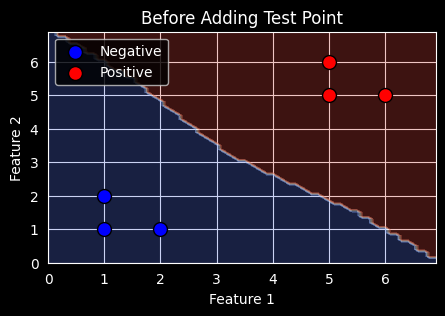

In [49]:
X_train = np.array(
    [[1, 1], [1, 2], [2, 1], [5, 5], [5, 6], [6, 5]]  # Class 0  # Class 1
)
y_train = np.array([0, 0, 0, 1, 1, 1])

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

plot_decision_boundary(knn, X_train, y_train, "Before Adding Test Point")

The classes seem to be perfectly separated. Assuming the model works perfectly, we deploy it in a real world setting, and the first new data comes in:

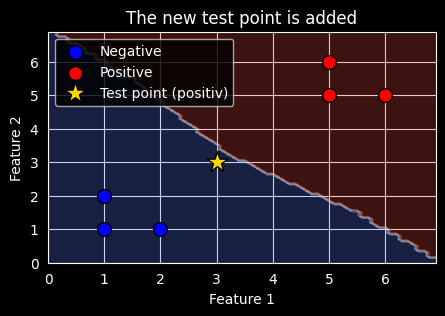

In [50]:
test_point = np.array([[3, 3]])
true_label = np.array([1])

pred_before = knn.predict(test_point)

plot_decision_boundary(
    knn, X_train, y_train, "The new test point is added", highlight_point=test_point
)

So, the predictions of the model may not be as good as we expect.

### Test Set & Information Leakage

To get a more realistic estimation of how a model is performing, we can put a part of the dataset aside and look at how the model performs on this set. The sklearn library has a function for this [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

Let's repeat the experiment on our own dataset for class wind:

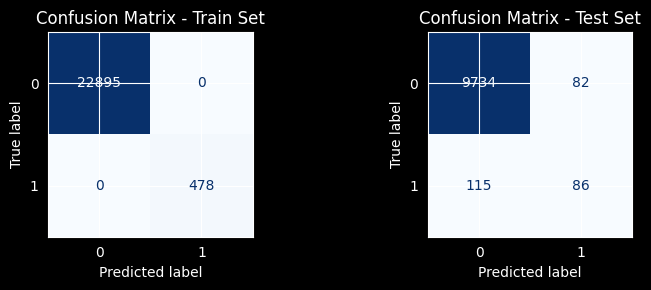

In [42]:
# Split data
X_train_bell, X_test_bell, y_train_bell, y_test_bell = train_test_split(
    bell_x,
    bell_y,
    test_size=0.3,
    random_state=42,
)

# Train model
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_bell, y_train_bell.reshape(-1))

# Predictions
y_train_pred = knn.predict(X_train_bell)
y_test_pred = knn.predict(X_test_bell)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))  # Side by side, smaller overall size

# Train confusion matrix
cm_train = confusion_matrix(y_train_bell, y_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train, display_labels=knn.classes_
)
disp_train.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix - Train Set")

# Test confusion matrix
cm_test = confusion_matrix(y_test_bell, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test, display_labels=knn.classes_
)
disp_test.plot(cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()

Assuming that the distribution of our data matches that of the "real data", this will usually give us a better estimation of how the model performs. But this is still not quite accurate for a dataset similar to ours, due to a problem referred to as data leakage.

Data leakage occurs when a model has access to information during training that would not be available at prediction time, leading to overly optimistic performance. Why is this problem relevant to us?

train_test_split splits the data randomly. If you apply it directly on the frame level, frames from the same original audio file may end up in both the training and test sets.

Since consecutive frames are highly correlated (they come from the same source), this violates the assumption that the test set is unseen data. As a result:

The model might "memorize" patterns from specific files and the evaluation metrics will be overly optimistic and misleading.

### Task 1: Avoiding Information Leakage in your Data Splits

**Implementation Task**: Split our dataset into training and test sets, making sure that all frames from the same original audio file end up in the same set. You can find our solution below.

In [43]:
# raise NotImplementedError
# train_files = TODO
# test_files = TODO

# X_train, Y_train = read_files(train_files, label_type="binary")
# X_test, Y_test = read_files(test_files, label_type="binary")

In [44]:
# solution
train_files = audio_features_paths[: int(len(audio_features_paths) * 0.8)]
test_files = audio_features_paths[int(len(audio_features_paths) * 0.8) :]

X_train, Y_train = read_files(train_files, label_type="binary")
X_test, Y_test = read_files(test_files, label_type="binary")

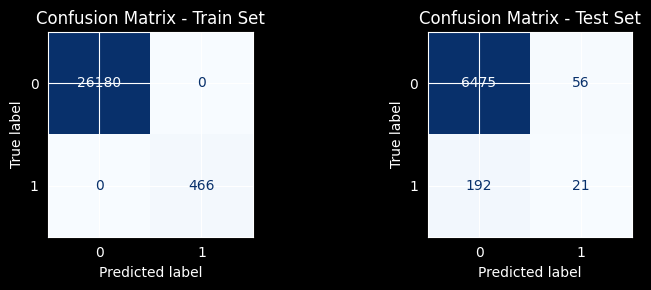

In [46]:
bell_x_train, bell_y_train = X_train, Y_train["bell_ringing"]
bell_x_test, bell_y_test = X_test, Y_test["bell_ringing"]

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(bell_x_train, bell_y_train.reshape(-1))

y_train_pred = knn.predict(bell_x_train)
y_test_pred = knn.predict(bell_x_test)


# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))  # Side by side, smaller overall size

# Train confusion matrix
cm_train = confusion_matrix(bell_y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train, display_labels=knn.classes_
)
disp_train.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix - Train Set")

# Test confusion matrix
cm_test = confusion_matrix(bell_y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test, display_labels=knn.classes_
)
disp_test.plot(cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()

### Validation Set

We have tried two models so far. Often when training a classifier we consider different model classes, and each with a set of hyper-parameters.

Could we use the performance on the test set to choose the best classifier?

No, the test set must not be used to choose the best classifier or to tune hyperparameters. Doing so leads to information leakage and overestimates the model's true performance.

The test set is our unseen data. If we select the model class and hyperparameters based on test performance, the model has indirectly seen the test data and the evaluation becomes unreliable. To avoid this, we put aside another section of data as the validation set.

In [51]:
train_files = audio_features_paths[: int(len(audio_features_paths) * 0.7)]
validation_files = audio_features_paths[
    int(len(audio_features_paths) * 0.7) : int(len(audio_features_paths) * 0.9)
]
test_files = audio_features_paths[int(len(audio_features_paths) * 0.9) :]

# So final split: 70% train, 20% val, 10% test

## Performance Metrics

See `01_classification_metrics.ipynb` for a more thorough description of the metrics. This is just a quick recap.

| Metric                   | Description                                                 | When It's Useful                                                       |
| ------------------------ | ----------------------------------------------------------- | ---------------------------------------------------------------------- |
| **Accuracy**             | % of correct predictions `(TP + TN) / Total`                | Simple, but **misleading with imbalanced data**                        |
| **Precision**            | How many predicted positives were correct: `TP / (TP + FP)` | Important when **false positives** are costly (e.g., spam filters)     |
| **Recall (Sensitivity)** | How many actual positives were caught: `TP / (TP + FN)`     | Critical when **false negatives** are costly (e.g., medical diagnosis) |
| **F1 Score**             | Harmonic mean of precision and recall                       | Good **balance** when classes are imbalanced                           |
| **ROC AUC**              | Measures ranking ability over all thresholds                | Good for **probabilistic models**; not sensitive to threshold          |
| **PR AUC**               | Area under Precision-Recall curve                           | Better than ROC AUC for **imbalanced data**                            |


In [53]:
# y_true: ground truth labels
# y_pred: predicted class labels (e.g., 0 or 1)
# y_scores: predicted probabilities or decision function scores

accuracy = accuracy_score(bell_y_test, y_test_pred)
precision = precision_score(bell_y_test, y_test_pred, zero_division=0)
recall = recall_score(bell_y_test, y_test_pred)
f1 = f1_score(bell_y_test, y_test_pred)
roc_auc = roc_auc_score(bell_y_test, y_test_pred)
pr_auc = average_precision_score(bell_y_test, y_test_pred)
weighted_acc = balanced_accuracy_score(bell_y_test, y_test_pred)

print(f"Accuracy:         {accuracy:.3f}")
print(f"Weighted Accuracy:{weighted_acc:.3f}")
print(f"Precision:        {precision:.3f}")
print(f"Recall:           {recall:.3f}")
print(f"F1 Score:         {f1:.3f}")
print(f"ROC AUC:          {roc_auc:.3f}")
print(f"PR AUC:           {pr_auc:.3f}")

Accuracy:         0.963
Weighted Accuracy:0.545
Precision:        0.273
Recall:           0.099
F1 Score:         0.145
ROC AUC:          0.545
PR AUC:           0.055


## 4. Binary Classification

Now we can move on to training classifiers. Let's start be training a very simple Decision Tree.
A **Decision Tree** is a model that splits data by asking feature-based questions, forming a tree structure.  

In [69]:
X_train, Y_train = read_files(train_files, label_type="binary")
X_test, Y_test = read_files(test_files, label_type="binary")
X_val, Y_val = read_files(validation_files, label_type="binary")

print(len(X_train))
# subsampling the training data to reduce run time
sample_size = 5000
indices = np.random.choice(len(X_train), size=sample_size, replace=False)

X_train = X_train[indices]
for c in CLASSES_NAMES:
    Y_train[c] = Y_train[c][indices]


bell_x_train, bell_y_train = X_train, Y_train["bell_ringing"]
bell_x_test, bell_y_test = X_test, Y_test["bell_ringing"]
bell_x_val, bell_y_val = X_val, Y_val["bell_ringing"]

23311


In [79]:
# Define the model
dt = DecisionTreeClassifier(random_state=42)

The DT classifier has several patameters we can experiment with. Let's pick a few to explore

In [80]:
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}
best_score = 0
best_params = None
best_model = None

In [82]:
import numpy as np

max_depths = param_grid["max_depth"]
min_splits = param_grid["min_samples_split"]

# Create result containers
scores_gini = np.zeros((len(max_depths), len(min_splits)))
scores_entropy = np.zeros((len(max_depths), len(min_splits)))

for i, max_depth in enumerate(max_depths):
    for j, min_samples_split in enumerate(min_splits):
        for criterion in param_grid["criterion"]:

            model = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                criterion=criterion,
                random_state=42,
            )
            model.fit(bell_x_train, bell_y_train)

            y_val_pred = model.predict(bell_x_val)
            score = balanced_accuracy_score(bell_y_val, y_val_pred)

            print(
                f"Params: max_depth={max_depth}, min_samples_split={min_samples_split}, criterion={criterion} --> Accuracy: {score:.4f}"
            )

            # Store score
            if criterion == "gini":
                scores_gini[i, j] = score
            else:
                scores_entropy[i, j] = score

            # Track best
            if score > best_score:
                best_score = score
                best_params = {
                    "max_depth": max_depth,
                    "min_samples_split": min_samples_split,
                    "criterion": criterion,
                }
                best_model = model

Params: max_depth=3, min_samples_split=2, criterion=gini --> Accuracy: 0.5766
Params: max_depth=3, min_samples_split=2, criterion=entropy --> Accuracy: 0.5358
Params: max_depth=3, min_samples_split=5, criterion=gini --> Accuracy: 0.5766
Params: max_depth=3, min_samples_split=5, criterion=entropy --> Accuracy: 0.5358
Params: max_depth=3, min_samples_split=10, criterion=gini --> Accuracy: 0.5766
Params: max_depth=3, min_samples_split=10, criterion=entropy --> Accuracy: 0.5358
Params: max_depth=5, min_samples_split=2, criterion=gini --> Accuracy: 0.5971
Params: max_depth=5, min_samples_split=2, criterion=entropy --> Accuracy: 0.5435
Params: max_depth=5, min_samples_split=5, criterion=gini --> Accuracy: 0.5971
Params: max_depth=5, min_samples_split=5, criterion=entropy --> Accuracy: 0.5435
Params: max_depth=5, min_samples_split=10, criterion=gini --> Accuracy: 0.5971
Params: max_depth=5, min_samples_split=10, criterion=entropy --> Accuracy: 0.5438
Params: max_depth=10, min_samples_split=2,

In [83]:
import matplotlib.pyplot as plt

def plot_heatmap(scores, title):
    plt.figure(figsize=(6, 4))
    im = plt.imshow(scores, cmap="viridis")

    plt.colorbar(im)

    plt.xticks(range(len(min_splits)), min_splits)
    plt.yticks(range(len(max_depths)), max_depths)

    plt.xlabel("min_samples_split")
    plt.ylabel("max_depth")
    plt.title(title)

    # Annotate values
    for i in range(len(max_depths)):
        for j in range(len(min_splits)):
            plt.text(j, i, f"{scores[i, j]:.3f}",
                     ha="center", va="center", color="white")

    plt.tight_layout()
    plt.show()

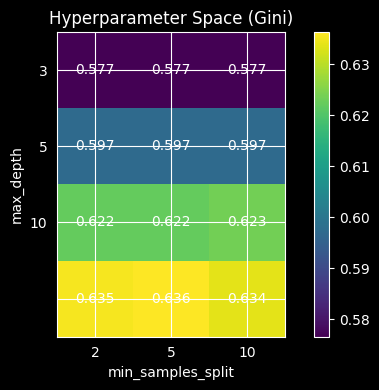

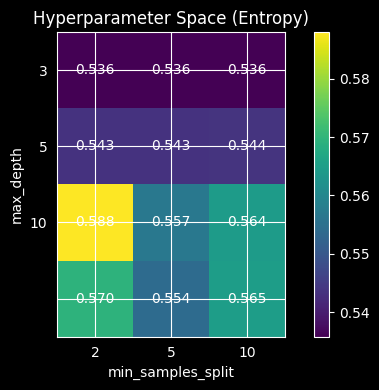

In [84]:
plot_heatmap(scores_gini, "Hyperparameter Space (Gini)")
plot_heatmap(scores_entropy, "Hyperparameter Space (Entropy)")

## 5. Multi-Label Classification

The classifiers we looked into were all **binary** classifiers, and simply distinguish if a datapoint belongs in a class or not. Among non-binary classification problems, two common sets of classes are **Multi-Label Classification** and **Multi-Class Classification**.

- Multi-Class: We have n possible classes, where each instance belongs to exactly one class.
- Multi-Label: We have n possible classes, and each instance can belong to multiple classes (or none).  

Which description fits our task better?

In our dataset we have a set of sound events that can happen simultaneously and in the same audio frame. This turns our problem into a multi-label classification problem.
One simple was of performing this type of classification is to have one binary classifier per class, working independently. Let's see how this works in practice.

In [85]:
X_train, Y_train = read_files(train_files, label_type="multilabel")
X_test, Y_test = read_files(test_files, label_type="multilabel")
X_val, Y_val = read_files(validation_files, label_type="multilabel")

# subsampling the training data to reduce run time
sample_size = 5000
indices = np.random.choice(len(X_train), size=sample_size, replace=False)

X_train = X_train[indices]
Y_train = Y_train[indices]

In [88]:
selected_classes = ["bell_ringing", "vacuum_cleaner"]
selected_indices = [CLASSES_NAMES.index(cls) for cls in selected_classes]

y_train = Y_train[:, selected_indices]
y_val = Y_val[:, selected_indices]
y_test = Y_test[:, selected_indices]

In [89]:
y_train.shape

(5000, 2)

### Baseline Classifier

Before training a proper classifier, let's establish a majority-class baseline for two classes (`["bell_ringing", "vacuum_cleaner"]`) simultaneously.

Sklearn provides a wrapper for classifiers that do not natively support multi-target classification: `MultiOutputClassifier`. This wrapper classifier works by fitting one classifier per target class and making predictions independently for each target. We could achieve the same by training multiple separate `BaselineClassifier` in a loop; this would also give us the chance to balance the dataset and tune hyperparameters separately. For convenience, we will use `MultiOutputClassifier` as it is more convenient and cleaner.

Let's wrap the `BaselineClassifier` into a `MultiOutputClassifier` and evaluate its performance on all classes on the validation set.

In [90]:
baseline_clf = MultiOutputClassifier(BaselineClassifier())
baseline_clf.fit(X_train, y_train)
Y_pred_baseline = baseline_clf.predict(X_val)

In [91]:
n_labels = y_val.shape[1]
baseline_bal_accs = [
    balanced_accuracy_score(y_val[:, i], Y_pred_baseline[:, i])
    for i in range(n_labels)
]
baseline_accs = [
    accuracy_score(y_val[:, i], Y_pred_baseline[:, i])
    for i in range(n_labels)
]
baseline_bal_acc_macro = np.mean(baseline_bal_accs)
baseline_acc_macro = np.mean(baseline_accs)

print(f"Baseline Macro-Avg Accuracy:          {baseline_acc_macro:.4f}")
print(f"Baseline Macro-Avg Balanced Accuracy: {baseline_bal_acc_macro:.4f}")

Baseline Macro-Avg Accuracy:          0.9516
Baseline Macro-Avg Balanced Accuracy: 0.5000


Let's use a Decision Tree in the same manner, and see how it performs on the validation set.

In [92]:
X = X_train
Y_multilabel = y_train

base_clf = DecisionTreeClassifier()

br_clf = MultiOutputClassifier(base_clf)

br_clf.fit(X, Y_multilabel)

Y_pred_dt = br_clf.predict(X_val)

In [94]:
n_labels = y_val.shape[1]
dt_bal_accs = []
dt_accs = []

for i in range(n_labels):
    dt_bal_accs.append(balanced_accuracy_score(y_val[:, i], Y_pred_dt[:, i]))
    dt_accs.append(accuracy_score(y_val[:, i], Y_pred_dt[:, i]))

dt_bal_acc_macro = np.mean(dt_bal_accs)
dt_acc_macro = np.mean(dt_accs)

print(f"Decision Tree Macro-Avg Accuracy:          {dt_acc_macro:.4f}")
print(f"Decision Tree Macro-Avg Balanced Accuracy: {dt_bal_acc_macro:.4f}")

Decision Tree Macro-Avg Accuracy:          0.9430
Decision Tree Macro-Avg Balanced Accuracy: 0.6972


## Task 2: 
**Implementation Task:** Train a [Random Forest Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) for multi-label classification and report your results. Take a look at the documentation and choose initial hyperparameters that sound reasonable and are suitable for your computational resources. You can find our solution below.

In [95]:
# raise NotImplementedError

In [97]:
# solution

X = X_train
Y_multilabel = y_train

base_clf = RandomForestClassifier(max_depth=10, n_estimators=500, random_state=42)

br_clf = MultiOutputClassifier(base_clf)

br_clf.fit(X, Y_multilabel)

Y_pred_rf = br_clf.predict(X_val)

In [98]:
n_labels = y_val.shape[1]
rf_bal_accs = [
    balanced_accuracy_score(y_val[:, i], Y_pred_rf[:, i])
    for i in range(n_labels)
]
rf_accs = [
    accuracy_score(y_val[:, i], Y_pred_rf[:, i])
    for i in range(n_labels)
]
rf_bal_acc_macro = np.mean(rf_bal_accs)
rf_acc_macro = np.mean(rf_accs)

print(f"Random Forest Macro-Avg Accuracy:          {rf_acc_macro:.4f}")
print(f"Random Forest Macro-Avg Balanced Accuracy: {rf_bal_acc_macro:.4f}")

Random Forest Macro-Avg Accuracy:          0.9680
Random Forest Macro-Avg Balanced Accuracy: 0.6771


### Summary: Classifier Comparison

The table below compares all three classifiers on the validation set for the selected classes (`bell_ringing`, `vacuum_cleaner`). Both metrics are macro-averaged across both classes.

In [99]:
classwise_bal_macro = { n: m for n, m in zip(selected_classes, list(zip(baseline_bal_accs, dt_bal_accs, rf_bal_accs)))}

results = pd.DataFrame(
    {
        "Classifier": ["Baseline (Majority Class)", "Decision Tree", "Random Forest"],
    } | classwise_bal_macro | {
        "Macro-Avg Accuracy": [baseline_acc_macro, dt_acc_macro, rf_acc_macro],
        "Macro-Avg Balanced Accuracy": [baseline_bal_acc_macro, dt_bal_acc_macro, rf_bal_acc_macro],
    }
).set_index("Classifier")

results.round(4)

,bell_ringing,vacuum_cleaner,Macro-Avg Accuracy,Macro-Avg Balanced Accuracy
Classifier,,,,
Baseline (Majority Class),0.5000,0.5000,0.9516,0.5000
Decision Tree,0.6384,0.7560,0.9430,0.6972
Random Forest,0.5465,0.8078,0.9680,0.6771


## 6. Multi-Class Classification

> As we discussed above, the project for this class is a **multi-label** classification problem, **NOT a multi-class one**. The following part of the tutorial is just for completeness, so that you get some hands-on experience with multi-class problems. See `read_files` to see how the labels are aggregated in this case! Feel free to skip this section if you just want to focus on the parts relevant for future tasks of the project.

In **binary classification** a model decides between two outcomes (for example, *bell ringing* vs. *not bell ringing*). In **multi-label classification** each frame can carry several labels at the same time. **Multi-class classification** is a third distinct setting: every input is assigned to exactly one class out of $C$ possible categories, and no frame belongs to two classes simultaneously.

In our dataset we treat each audio frame as belonging to one of **15 sound event labels** (e.g. `keyboard_typing`, `footsteps`, `vacuum_cleaner`, ...). The model must discriminate between all 15 categories at once instead of solving 15 independent yes/no problems.

Key differences from binary classification:

| Aspect | Binary | Multi-Class (here) |
|---|---|---|
| Output | $\{0, 1\}$ | $\{0, 1, \ldots, 14\}$ |
| Balanced accuracy | Average recall over 2 classes | Average recall over all 15 classes |
| Confusion matrix | $2 \times 2$ | $15 \times 15$, revealing which classes are confused |

In [100]:
X_train, Y_train = read_files(train_files, label_type="multiclass")
X_test, Y_test = read_files(test_files, label_type="multiclass")
X_val, Y_val = read_files(validation_files, label_type="multiclass")

# subsample training data to reduce run time
sample_size = 5000
indices = rng.choice(len(X_train), size=sample_size, replace=False)
X_train = X_train[indices]
Y_train = Y_train[indices]

### Majority-Class Baseline

Before training a real classifier it is good practice to establish a **baseline**, the simplest possible model whose score sets the floor that any meaningful classifier must beat.

Here we reuse the same idea as in the binary case: always predict the **most frequent class** in the training set. With 15 unbalanced classes the majority label will dominate predictions, which is exactly why **balanced accuracy** (average per-class recall) is a better metric than raw accuracy here.

In [180]:
class MulticlassBaselineClassifier:

    def __init__(self):
        self.majority_class = None

    def fit(self, x_train: np.ndarray, y_train: np.ndarray) -> None:
        values, counts = np.unique(y_train.ravel(), return_counts=True)
        self.majority_class = values[np.argmax(counts)]

    def predict(self, x: np.ndarray) -> np.ndarray:
        return np.full(x.shape[0], self.majority_class)


baseline_mc = MulticlassBaselineClassifier()
baseline_mc.fit(X_train, Y_train)
Y_pred_baseline = baseline_mc.predict(X_test)

Baseline Balanced Accuracy: 0.0667


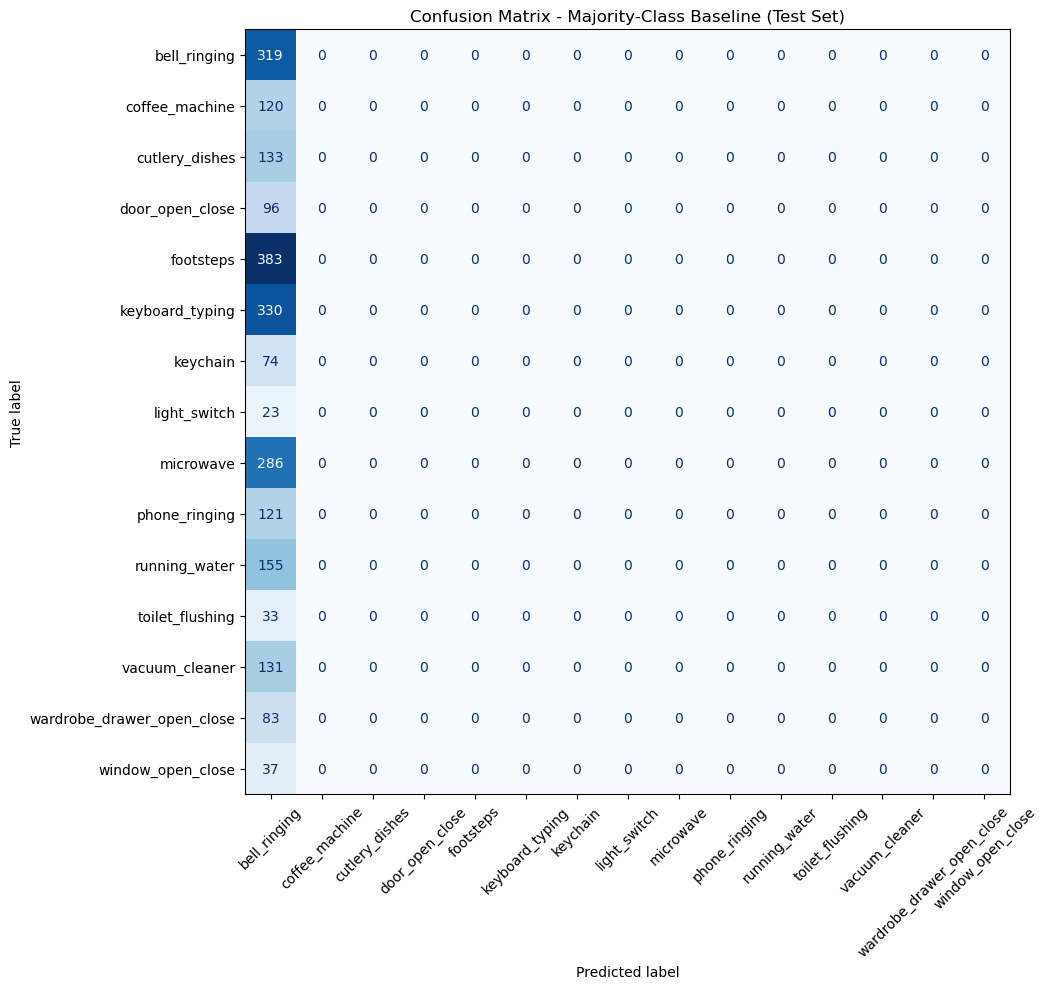

In [181]:
bal_acc_baseline = balanced_accuracy_score(Y_test, Y_pred_baseline)
print(f"Baseline Balanced Accuracy: {bal_acc_baseline:.4f}")

cm_baseline = confusion_matrix(
    Y_test, Y_pred_baseline, labels=range(len(CLASSES_NAMES))
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline, display_labels=CLASSES_NAMES
)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap="Blues", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Majority-Class Baseline (Test Set)")
plt.tight_layout()
plt.show()

### Decision Tree Classifier

Now let's train a proper classifier. A **Decision Tree** recursively partitions the feature space into regions that are as pure as possible with respect to the class labels. Unlike the baseline, it can learn complex, non-linear boundaries across all 15 classes in a single model.

In [182]:
br_clf = DecisionTreeClassifier()

br_clf.fit(X_train, Y_train)

Y_pred = br_clf.predict(X_test)

Balanced Accuracy: 0.1959


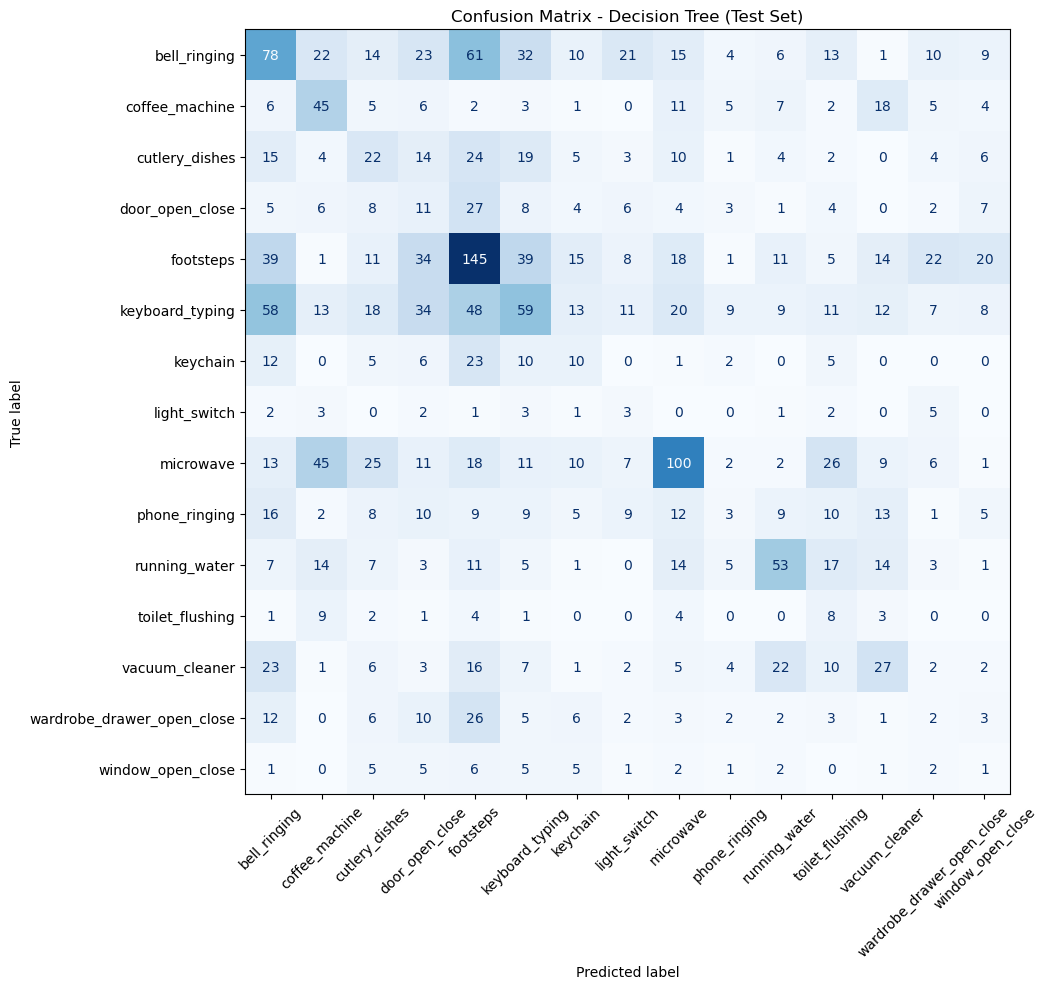

In [183]:
bal_acc = balanced_accuracy_score(Y_test, Y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

cm = confusion_matrix(Y_test, Y_pred, labels=range(len(CLASSES_NAMES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_NAMES)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap="Blues", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix - Decision Tree (Test Set)")
plt.tight_layout()
plt.show()